# Graph III

In [1]:
from typing import TypedDict # Imports all the data types we need
from langgraph.graph import StateGraph

In [2]:
# 首先编码 状态模式 / 智能体状态
class AgentState(TypedDict):
    name: str
    age: str
    final: str

In [5]:
# 定义两个节点函数（执行操作）
def first_node(state:AgentState) -> AgentState:
    """This is the first node of our sequence"""

    state["final"] = f'Hi {state["name"]}!'
    return state

def second_node(state:AgentState) -> AgentState:
    """This is the second node of our sequence"""

    state["final"] = state["final"] + f' You are {state["age"]} years old!'   # 注意这里要 + 之前的 state["final"]，否则会覆盖

    return state

In [6]:
graph = StateGraph(AgentState)

graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)

graph.set_entry_point("first_node")   # 设置入口点
graph.add_edge("first_node", "second_node")    # 有向边，数据流向是从 first_node -> second_node
graph.set_finish_point("second_node")   # 设置终点
app = graph.compile()

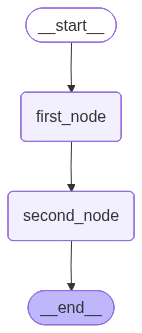

In [7]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [8]:
result = app.invoke({"name": "Charlie", "age": 20})
print(result)

{'name': 'Charlie', 'age': 20, 'final': 'Hi Charlie! You are 20 years old!'}
